In [1]:
!pip install -r ../requirements.txt

In [2]:
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())

12.8
True


In [3]:
import sys
import importlib
sys.path.append("..")

# Import your modules first
import helper
import obelix
import algorithms.d3qn_lstm_rep_complex_v2 as d3qn_per_agent
import configurations.config_p3_sub4_v2 as config

# Reload them to pick up any changes
importlib.reload(helper)
importlib.reload(obelix)
importlib.reload(d3qn_per_agent)
importlib.reload(config)

device used:  cuda
device used:  cuda


<module 'configurations.config_p3_sub4_v2' from 'c:\\Users\\hgoel\\MTech_Resources\\DRL\\Capstone_Project\\CS780-OBELIX\\run_scripts\\..\\configurations\\config_p3_sub4_v2.py'>

In [4]:
from helper import plotQuantity
from obelix import OBELIX
from algorithms.d3qn_lstm_rep_complex_v2 import D3QN_PER
from configurations.config_p3_sub4_v2 import config

In [5]:
print(config)

{'seed': 333, 'gamma': 0.99, 'bufferSize': 1000000, 'batchSize': 64, 'optimizerFn': <class 'torch.optim.adam.Adam'>, 'optimizerLR': 0.0001, 'MAX_TRAIN_EPISODES': 600, 'MAX_EVAL_EPISODES': 5, 'updateFrequency': 40, 'explorationStrategyTrainFn': <function selectEpsilonGreedyActionREP_COMP at 0x000001278207C5E0>, 'explorationStrategyEvalFn': <function selectGreedyActionREP_COMP at 0x0000012781E093A0>, 'max_steps': 1000, 'epsilon': 1.0, 'eps_decay_strategy': [('exponential', {'s': 0, 'e': 599, 'ival': 1.0, 'fval': 0.002})], 'device': device(type='cuda'), 'delta': 0.99, 'tau': 0.001, 'alpha': 0.42, 'beta': 0.58, 'beta_rate': 0.0002, 'f_hDim': [324, 256], 'lstm_hDim': 128, 'model_path': '../model_weights_phase3_sub4_v2', 'loss_fn': 'HuberLoss', 'seq_len': 20, 'burn_in': 5, 'minSamples': 10, 'for_hDim': [224, 128], 'inv_hDim': [224, 128], 'alpha_f': 0.12, 'beta_i': 0.15, 'eta': 0.07}


In [6]:
env = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=True,
    difficulty=3,
    box_speed=4,
)
D3QN_PER_LSTM_with_REP_BAD_HEAD_Agent = D3QN_PER(env, config)

In [7]:
d3qnPerTrainRewardsList, d3qnPerTrainTimeList, d3qnPerEvalRewardsList, d3qnPerWallClockTimeList, d3qnPerTotalStepsList, d3qnPerFinalEvalReward = D3QN_PER_LSTM_with_REP_BAD_HEAD_Agent.runD3QN_PER()

Episode 1: TR -11933.000 | TT 3.099 | TS 263
Episode 2: TR -7967.000 | TT 10.150 | TS 1000
Episode 3: TR -28974.000 | TT 17.156 | TS 1000
Episode 4: TR 1658.000 | TT 20.723 | TS 474
Episode 5: TR -18583.000 | TT 27.632 | TS 1000
Episode 6: TR -23470.000 | TT 34.568 | TS 1000
Episode 7: TR -39668.000 | TT 41.680 | TS 1000
Episode 8: TR -24567.000 | TT 48.412 | TS 1000
Episode 9: TR -6469.000 | TT 55.421 | TS 1000
Episode 10: TR -26870.000 | TT 62.409 | TS 1000
Episode 11: TR -2984.000 | TT 119.946 | TS 1000
Episode 12: TR -84771.000 | TT 170.975 | TS 1000
Episode 13: TR -890.000 | TT 209.118 | TS 1000
Episode 14: TR -66584.000 | TT 241.398 | TS 1000
Episode 15: TR -17371.000 | TT 272.946 | TS 1000
Episode 16: TR -19776.000 | TT 303.667 | TS 1000
Episode 17: TR -29669.000 | TT 334.497 | TS 1000
Episode 18: TR -10268.000 | TT 386.169 | TS 1000
Episode 19: TR -66377.000 | TT 442.019 | TS 1000
Episode 20: TR -57470.000 | ER -944.600 | TT 481.401 | WC 517.533 | TS 1000
Episode 21: TR -27070.

In [8]:
import numpy as np
print(f"D3QN_PER_LSTM_with_REP_BAD_HEAD Final Evaluation Reward: {np.mean(d3qnPerFinalEvalReward).item()}")

D3QN_PER_LSTM_with_REP_BAD_HEAD Final Evaluation Reward: -891.0


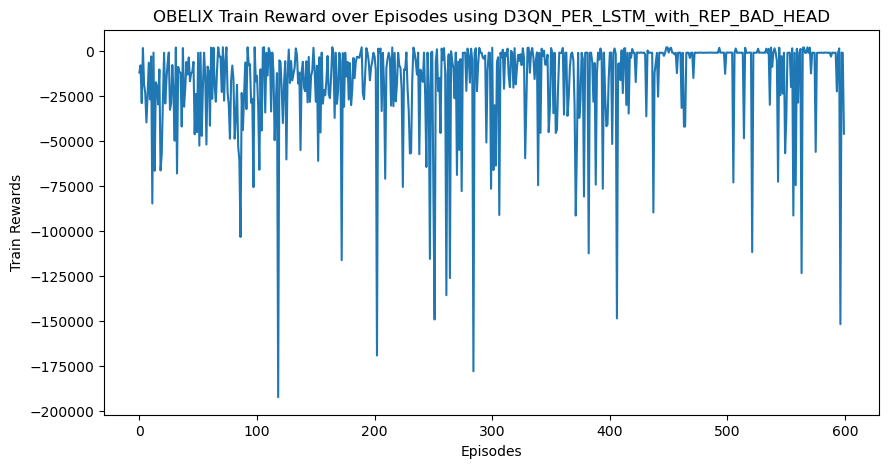

In [9]:
plotQuantity(
    d3qnPerTrainRewardsList, 
    len(d3qnPerTrainRewardsList), 
    descriptionList = ["Episodes", "Train Rewards", "OBELIX Train Reward over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

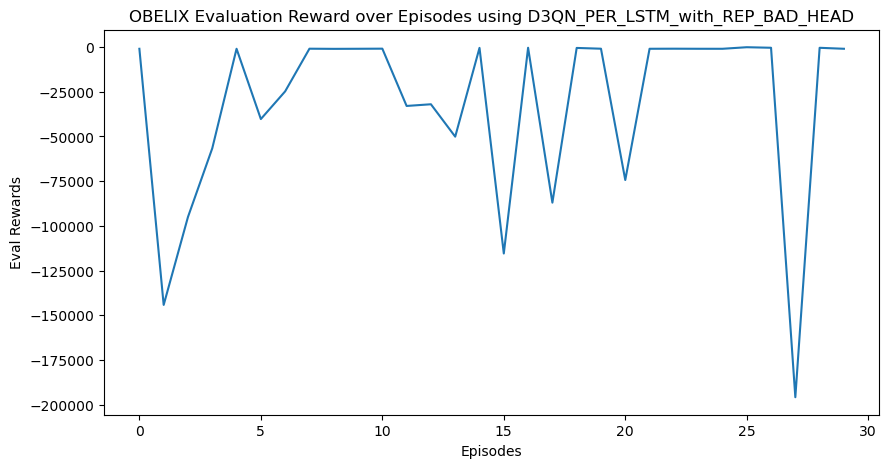

In [10]:
plotQuantity(
    d3qnPerEvalRewardsList, 
    len(d3qnPerEvalRewardsList), 
    descriptionList = ["Episodes", "Eval Rewards", "OBELIX Evaluation Reward over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

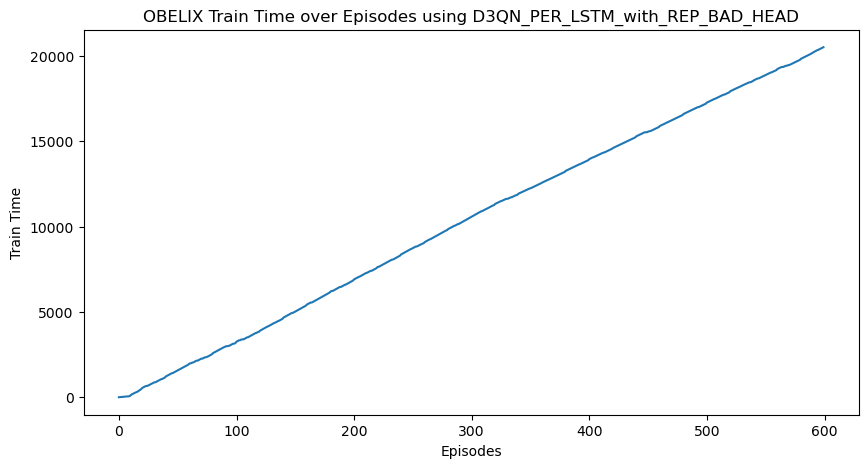

In [11]:
plotQuantity(
    d3qnPerTrainTimeList, 
    len(d3qnPerTrainTimeList), 
    descriptionList = ["Episodes", "Train Time", "OBELIX Train Time over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

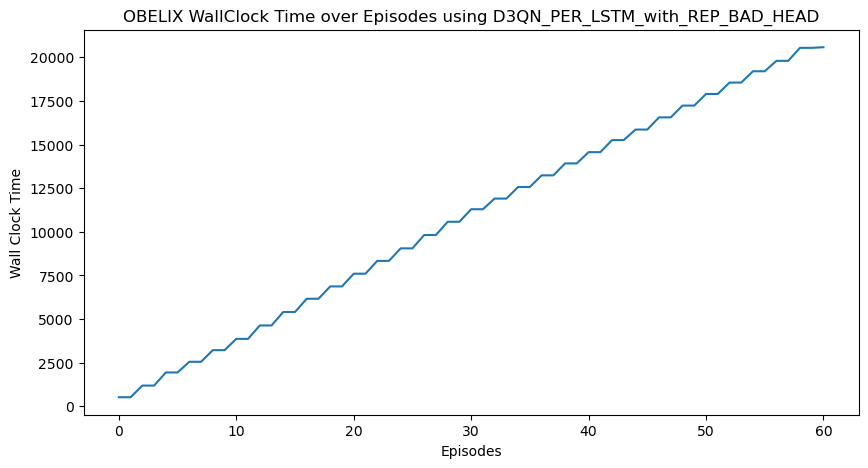

In [12]:
plotQuantity(
    d3qnPerWallClockTimeList, 
    len(d3qnPerWallClockTimeList), 
    descriptionList = ["Episodes", "Wall Clock Time", "OBELIX WallClock Time over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

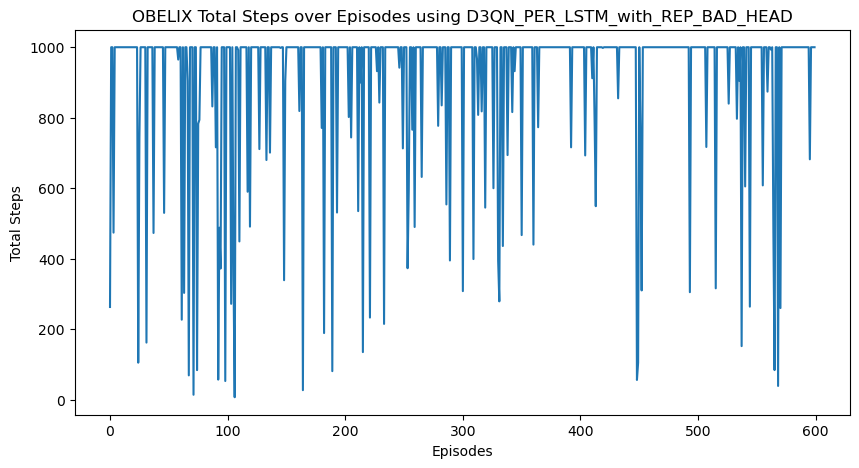

In [13]:
plotQuantity(
    d3qnPerTotalStepsList, 
    len(d3qnPerTotalStepsList), 
    descriptionList = ["Episodes", "Total Steps", "OBELIX Total Steps over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)